# PlantVillage Dataset Analysis

Initial exploration of the PlantVillage dataset before building the transfer learning model.

## Imports and Setup

In [90]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image
import tensorflow as tf
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from matplotlib.colors import LinearSegmentedColormap
from sklearn.metrics import classification_report

## Dataset Exploration

In [91]:
data_path = Path("../data/raw/plantvillage/PlantVillage")

train_path = data_path / "train"
val_path = data_path / "val"

print("Train exists:", train_path.exists())
print("Validation exists:", val_path.exists())

Train exists: True
Validation exists: True


## Class Distribution

In [92]:
train_counts = {}

for class_folder in train_path.iterdir():
    if class_folder.is_dir():
        image_count = len(list(class_folder.glob("*")))
        train_counts[class_folder.name] = image_count

class_distribution = pd.DataFrame(
    train_counts.items(),
    columns=["Class", "Train images"]
)

class_distribution = class_distribution.sort_values(
    "Train images",
    ascending=False
)

class_distribution

,Class,Train images
15,Orange___Haunglongbing_(Citrus_greening),4405
37,Tomato___Tomato_Yellow_Leaf_Curl_Virus,4286
24,Soybean___healthy,4072
16,Peach___Bacterial_spot,1838
28,Tomato___Bacterial_spot,1702
31,Tomato___Late_blight,1527
25,Squash___Powdery_mildew,1468
33,Tomato___Septoria_leaf_spot,1417
34,Tomato___Spider_mites Two-spotted_spider_mite,1341
3,Apple___healthy,1316


In [93]:
val_counts = {}

for class_folder in val_path.iterdir():
    if class_folder.is_dir():
        image_count = len(list(class_folder.glob("*")))
        val_counts[class_folder.name] = image_count

In [94]:
class_distribution = pd.DataFrame({
    "Train": train_counts,
    "Validation": val_counts
})

class_distribution["Total"] = (
    class_distribution["Train"] + class_distribution["Validation"]
)

class_distribution

,Train,Validation,Total
Apple___Apple_scab,504,126,630
Apple___Black_rot,496,125,621
Apple___Cedar_apple_rust,220,55,275
Apple___healthy,1316,329,1645
Blueberry___healthy,1202,300,1502
Cherry_(including_sour)___healthy,684,170,854
Cherry_(including_sour)___Powdery_mildew,842,210,1052
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot,410,103,513
Corn_(maize)___Common_rust_,953,239,1192
Corn_(maize)___healthy,929,233,1162


In [95]:
tomato_distribution = class_distribution[
    class_distribution.index.str.startswith("Tomato")
]

tomato_distribution

,Train,Validation,Total
Tomato___Bacterial_spot,1702,425,2127
Tomato___Early_blight,800,200,1000
Tomato___healthy,1273,318,1591
Tomato___Late_blight,1527,382,1909
Tomato___Leaf_Mold,761,191,952
Tomato___Septoria_leaf_spot,1417,354,1771
Tomato___Spider_mites Two-spotted_spider_mite,1341,335,1676
Tomato___Target_Spot,1123,281,1404
Tomato___Tomato_mosaic_virus,299,74,373
Tomato___Tomato_Yellow_Leaf_Curl_Virus,4286,1071,5357


### Class Selection

For this project, we selected three tomato leaf classes:

- Healthy
- Early blight
- Late blight

The classes are not perfectly balanced, but contain enough images for a small transfer learning experiment. Using classes from the same plant species also makes the classification task more meaningful, since the model must learn disease-related visual features rather than simply distinguishing between different plant species.

---

## Visual Analysis

In [96]:
selected_classes = [
    "Tomato___healthy",
    "Tomato___Early_blight",
    "Tomato___Late_blight"
]

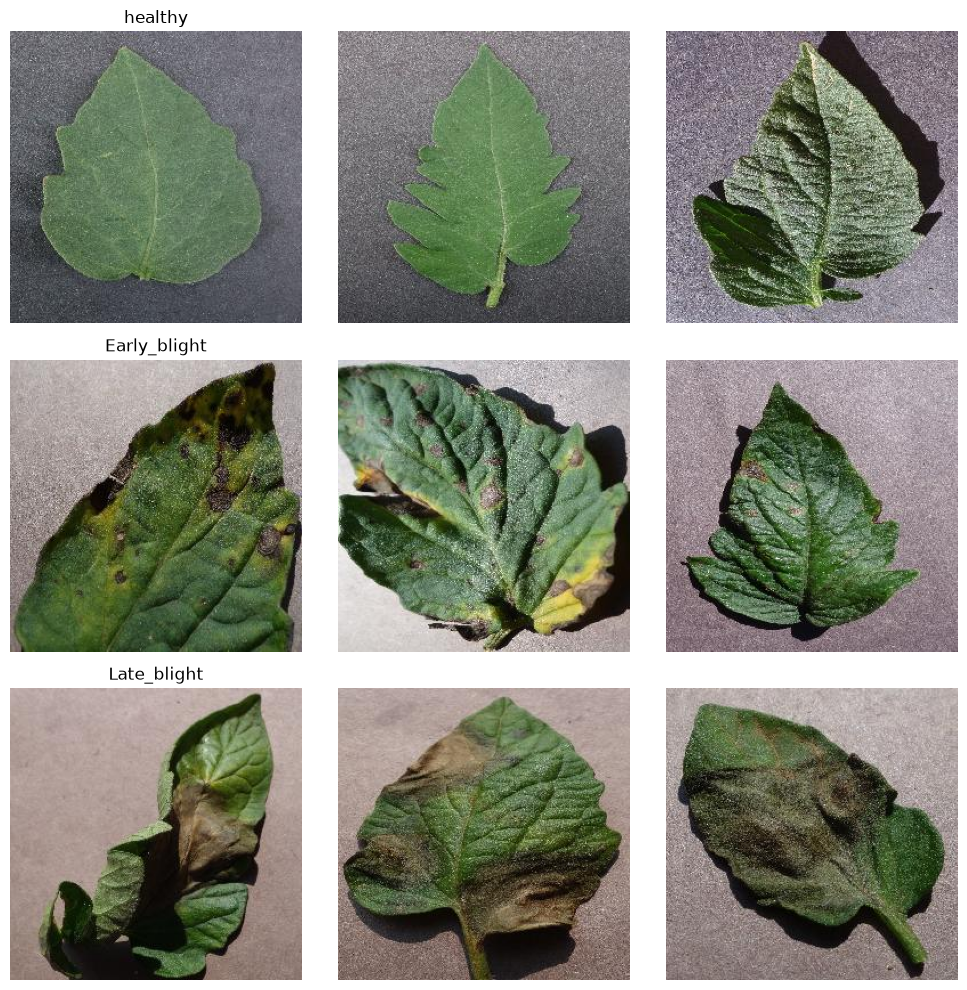

In [97]:
fig, axes = plt.subplots(3, 3, figsize=(10, 10))

for row, class_name in enumerate(selected_classes):
    class_path = train_path / class_name
    image_paths = list(class_path.glob("*"))[:3]

    for col, image_path in enumerate(image_paths):
        image = plt.imread(image_path)

        axes[row, col].imshow(image)
        axes[row, col].axis("off")

        if col == 0:
            axes[row, col].set_title(class_name.replace("Tomato___", ""))

plt.tight_layout()
plt.show()

### Visual observations

The sample images show visible differences between the three classes:

- **Healthy:** The leaves appear mostly green with a relatively even color and no obvious brown damaged areas.
- **Early blight:** The leaves show smaller brown or dark spots while much of the leaf remains green.
- **Late blight:** The examples show larger brown or damaged areas, with some leaves appearing dry or more severely affected.

These initial observations suggest that color, texture, and the size and distribution of damaged areas may be useful visual features for distinguishing between the classes.

In [98]:
image_sizes = []

for class_name in selected_classes:
    class_path = train_path / class_name

    for image_path in class_path.glob("*"):
        with Image.open(image_path) as img:
            image_sizes.append(img.size)

set(image_sizes)

{(256, 256)}

### Image Size

All images in the selected classes have a resolution of **256 × 256 pixels**.

This provides a consistent starting point for preprocessing. The images can later be resized to match the input size required by the selected pre-trained model.

---

# Transfer Learning

In [99]:
print(tf.__version__)

2.21.0


### Dataset Preparation

In [100]:
selected_classes = [
    "Tomato___healthy",
    "Tomato___Early_blight",
    "Tomato___Late_blight"
]

img_size = (224, 224)
batch_size = 32

In [101]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    labels="inferred",
    label_mode="categorical",
    class_names=selected_classes,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=True
)

Found 3600 files belonging to 3 classes.


In [102]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    val_path,
    labels="inferred",
    label_mode="categorical",
    class_names=selected_classes,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=False
)

Found 900 files belonging to 3 classes.


---
### MobileNetV2

In [103]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False, # tar bort MobileNetV2:s ursprungliga klassificeringsdel
    weights="imagenet" # modellen kommer redan tränad på ImageNet
)

base_model.trainable = False # basmodellens vikter fryses, så inte hela modellen tränas om

### Model Training

In [104]:
model = tf.keras.Sequential([
    tf.keras.Input(shape=(224, 224, 3)),
    tf.keras.layers.Rescaling(1./127.5, offset=-1),
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(3, activation="softmax")
])

In [105]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,261,827 (8.63 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [106]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [107]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5


c:\Users\emmyk\dev\tdm\plant-disease-detection\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


113/113 ━━━━━━━━━━━━━━━━━━━━ 35s 287ms/step - accuracy: 0.8178 - loss: 0.4515 - val_accuracy: 0.9044 - val_loss: 0.2504
Epoch 2/5
113/113 ━━━━━━━━━━━━━━━━━━━━ 31s 276ms/step - accuracy: 0.9281 - loss: 0.2102 - val_accuracy: 0.9289 - val_loss: 0.1888
Epoch 3/5
113/113 ━━━━━━━━━━━━━━━━━━━━ 32s 281ms/step - accuracy: 0.9433 - loss: 0.1673 - val_accuracy: 0.9422 - val_loss: 0.1621
Epoch 4/5
113/113 ━━━━━━━━━━━━━━━━━━━━ 31s 279ms/step - accuracy: 0.9506 - loss: 0.1474 - val_accuracy: 0.9444 - val_loss: 0.1489
Epoch 5/5
113/113 ━━━━━━━━━━━━━━━━━━━━ 33s 288ms/step - accuracy: 0.9553 - loss: 0.1293 - val_accuracy: 0.9478 - val_loss: 0.1380


### Initial Training Results

After 5 epochs, the model achieved:

- **Training accuracy:** 95.58%
- **Validation accuracy:** 94.78%
- **Training loss:** 0.1282
- **Validation loss:** 0.1536

The training and validation results are close, suggesting that the model generalizes well to unseen data. There are currently no clear signs of significant overfitting.

---

# Model Evaluation

To evaluate the model, we first examine how the training and validation accuracy and loss changed during training.

Här jämför vi:

Training Accuracy = hur bra modellen klassificerar bilder den tränar på.
Validation Accuracy = hur bra den klassificerar bilder som inte används för att uppdatera modellen.

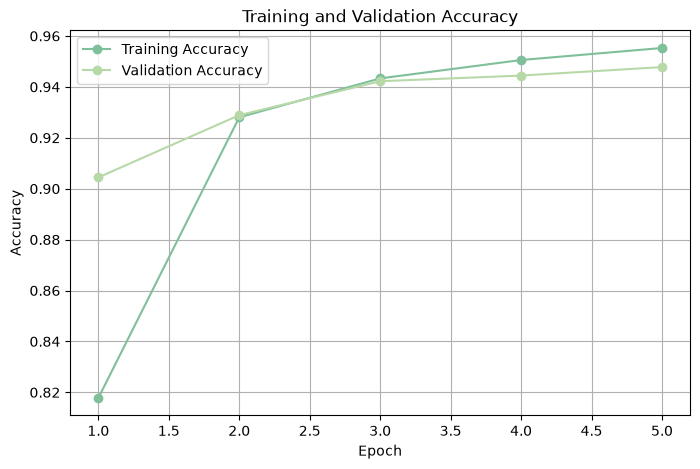

In [108]:
accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]

epochs = range(1, len(accuracy) + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs, accuracy,
    marker="o",
    color="#7FBF9A",
    label="Training Accuracy"
)

plt.plot(
    epochs, val_accuracy,
    marker="o",
    color="#B7D9A8",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

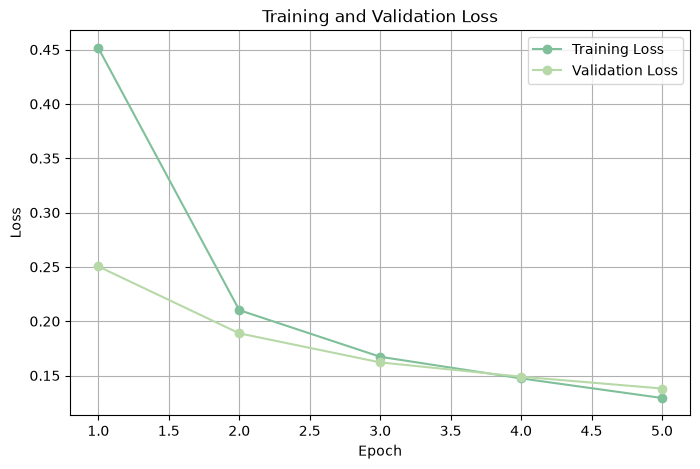

In [109]:
loss = history.history["loss"]
val_loss = history.history["val_loss"]

plt.figure(figsize=(8, 5))

plt.plot(
    epochs, loss,
    marker="o",
    color="#7FBF9A",
    label="Training Loss"
)

plt.plot(
    epochs, val_loss,
    marker="o",
    color="#B7D9A8",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

### Training Evaluation

The model improved quickly during the first epochs. Training accuracy increased from approximately 81% to 95.6%, while validation accuracy reached 94.8%.

Training and validation accuracy remain close throughout the later epochs, indicating that the model generalizes well to unseen data.

Both training and validation loss decreased substantially. Validation loss begins to level off after approximately 3–4 epochs and increases slightly in the final epoch, while training loss continues to decrease. This could indicate the beginning of overfitting, but the difference is small and there are no clear signs of significant overfitting.

Overall, the results suggest that the frozen MobileNetV2 features work well for distinguishing between the three tomato leaf classes.

---

# Confusion matrix

In [110]:
y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = model.predict(images, verbose=0)

    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(predictions, axis=1))

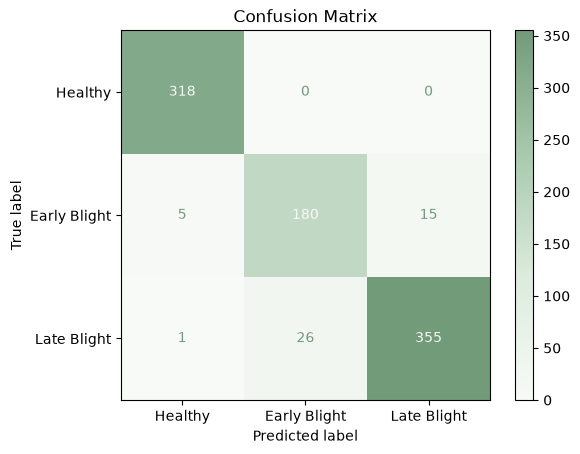

In [111]:
cm = confusion_matrix(y_true, y_pred)

display_labels = [
    "Healthy",
    "Early Blight",
    "Late Blight"
]

pastel_green = LinearSegmentedColormap.from_list(
    "pastel_green",
    ["#F7FAF7", "#DCEBDD", "#A8C9AD", "#729B7A"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=display_labels
)

disp.plot(cmap=pastel_green)
plt.title("Confusion Matrix")
plt.show()

### Confusion Matrix Analysis

The confusion matrix shows that the model performs well across all three classes.

- **Healthy:** All 318 images were classified correctly.
- **Early Blight:** 192 of 200 images were classified correctly. Most errors were confused with Late Blight.
- **Late Blight:** 351 of 382 images were classified correctly. The majority of errors were classified as Early Blight.

An important pattern is that the model rarely confuses diseased leaves with healthy leaves. Instead, most errors occur between Early Blight and Late Blight.

This suggests that the model has learned to recognize signs of disease effectively, but distinguishing between the two visually similar diseases is more challenging.

Overall, the model correctly classified **861 out of 900 validation images (95.7%)**.

---

# Classification report

In [112]:
report = classification_report(
    y_true,
    y_pred,
    target_names=display_labels
)

print(report)

              precision    recall  f1-score   support

     Healthy       0.98      1.00      0.99       318
Early Blight       0.87      0.90      0.89       200
 Late Blight       0.96      0.93      0.94       382

    accuracy                           0.95       900
   macro avg       0.94      0.94      0.94       900
weighted avg       0.95      0.95      0.95       900



### Classification Report Analysis

The classification report confirms the strong overall performance of the model, with an accuracy of approximately **96%**.

- **Healthy** achieved perfect precision, recall, and F1-score (1.00).
- **Early Blight** achieved a high recall of 0.96, meaning that most Early Blight cases were detected. However, its lower precision of 0.86 shows that some Late Blight images were incorrectly classified as Early Blight.
- **Late Blight** achieved high precision of 0.98 and an F1-score of 0.95, but its recall of 0.92 shows that some Late Blight cases were missed.

The results support the pattern seen in the confusion matrix: the main challenge for the model is distinguishing between Early Blight and Late Blight, while healthy leaves are clearly separated from diseased leaves.

---

### Prediction Examples

To visually evaluate the model's predictions, examples were selected from each of the three classes.

Since the validation dataset is loaded without shuffling, simply selecting the first batch would only show images from the first class. Therefore, three images from each class were selected to create a more representative comparison.

The predictions include the model's confidence score to show not only whether the classification was correct, but also how confident the model was in its decision.

In [113]:
class_names = ["Healthy", "Early Blight", "Late Blight"]

images_by_class = {0: [], 1: [], 2: []}
labels_by_class = {0: [], 1: [], 2: []}

for images, labels in val_ds:
    true_labels = np.argmax(labels.numpy(), axis=1)

    for image, true_label in zip(images, true_labels):
        if len(images_by_class[true_label]) < 3:
            images_by_class[true_label].append(image)
            labels_by_class[true_label].append(true_label)

    if all(len(images_by_class[i]) == 3 for i in range(3)):
        break

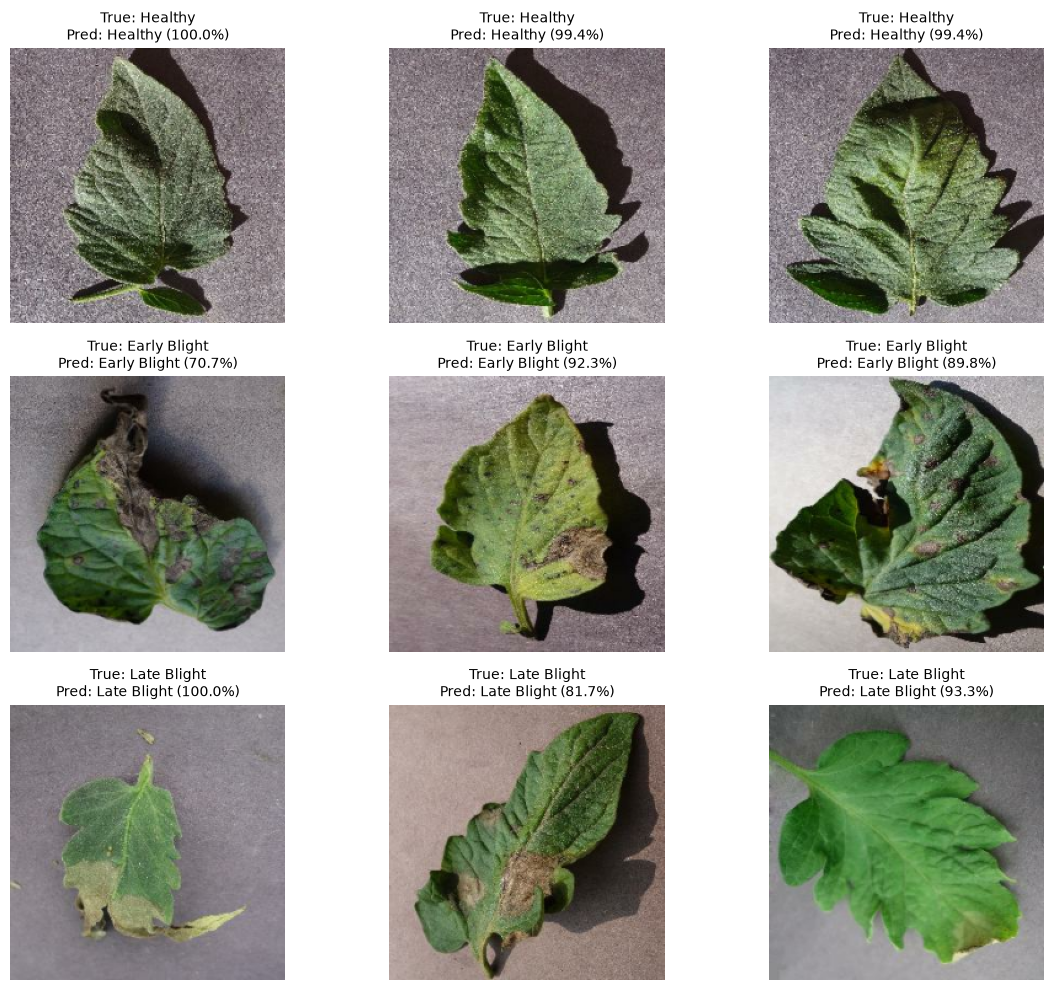

In [114]:
plt.figure(figsize=(12, 10))

plot_index = 1

for class_id in range(3):
    images = tf.stack(images_by_class[class_id])
    predictions = model.predict(images, verbose=0)

    predicted_labels = np.argmax(predictions, axis=1)
    confidence = np.max(predictions, axis=1)

    for i in range(3):
        plt.subplot(3, 3, plot_index)

        plt.imshow(images[i].numpy().astype("uint8"))
        plt.axis("off")

        true_name = class_names[class_id]
        pred_name = class_names[predicted_labels[i]]

        plt.title(
            f"True: {true_name}\n"
            f"Pred: {pred_name} ({confidence[i]:.1%})",
            fontsize=10
        )

        plot_index += 1

plt.tight_layout()
plt.show()

### Prediction Analysis

The prediction examples show that the model correctly classified all selected images from the three classes.

The model was particularly confident when identifying healthy leaves, with confidence scores close to 100%. Predictions for Early Blight were also consistently strong, although confidence was slightly lower.

Late Blight showed greater variation in confidence. While two examples were classified with high confidence, one prediction had a confidence of only 69.5%.

This supports the previous evaluation results: healthy leaves are clearly distinguished, while the distinction between Early Blight and Late Blight is more challenging for the model.

---

### Misclassified Predictions

To better understand the model's limitations, we examine examples from the validation set that were classified incorrectly.

In [115]:
misclassified_images = []
misclassified_true = []
misclassified_pred = []
misclassified_confidence = []

for images, labels in val_ds:
    predictions = model.predict(images, verbose=0)

    true_labels = np.argmax(labels.numpy(), axis=1)
    predicted_labels = np.argmax(predictions, axis=1)
    confidence = np.max(predictions, axis=1)

    for image, true_label, pred_label, conf in zip(
        images,
        true_labels,
        predicted_labels,
        confidence
    ):
        if true_label != pred_label:
            misclassified_images.append(image)
            misclassified_true.append(true_label)
            misclassified_pred.append(pred_label)
            misclassified_confidence.append(conf)

print(f"Misclassified images: {len(misclassified_images)}")

Misclassified images: 47


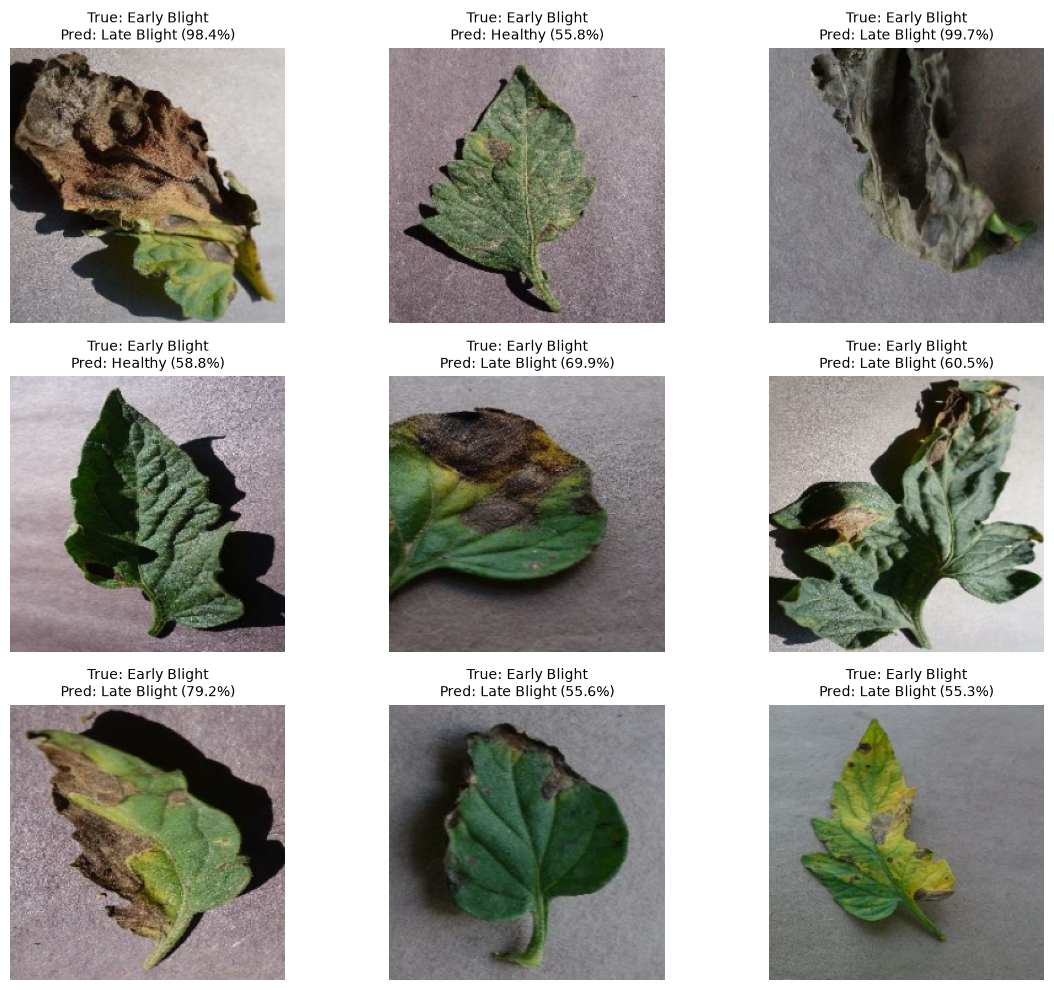

In [116]:
plt.figure(figsize=(12, 10))

for i in range(min(9, len(misclassified_images))):
    plt.subplot(3, 3, i + 1)

    plt.imshow(
        misclassified_images[i].numpy().astype("uint8")
    )
    plt.axis("off")

    true_name = class_names[misclassified_true[i]]
    pred_name = class_names[misclassified_pred[i]]

    plt.title(
        f"True: {true_name}\n"
        f"Pred: {pred_name} ({misclassified_confidence[i]:.1%})",
        fontsize=10
    )

plt.tight_layout()
plt.show()

### Misclassification Analysis

The misclassified examples show that most errors occur between Early Blight and Late Blight, which supports the pattern observed in the confusion matrix.

Several misclassified images contain large brown or damaged areas that visually resemble characteristics seen in both disease classes. In some cases, the model makes an incorrect prediction with very high confidence, including Early Blight images predicted as Late Blight with over 90% confidence.

This suggests that the main limitation is not distinguishing healthy from diseased leaves, but separating the two visually similar disease classes.

It is also important to note that the dataset labels are treated as ground truth. Visual inspection alone cannot determine whether an individual dataset label is incorrect, but the examples highlight potential visual overlap between the classes.

---

### Prediction Confidence
We already have y_true and y_pred but now we need confidence for the whole validation-set:

In [117]:
correct_confidence = []
incorrect_confidence = []

for images, labels in val_ds:
    predictions = model.predict(images, verbose=0)

    true_labels = np.argmax(labels.numpy(), axis=1)
    predicted_labels = np.argmax(predictions, axis=1)
    confidence = np.max(predictions, axis=1)

    for true_label, pred_label, conf in zip(
        true_labels,
        predicted_labels,
        confidence
    ):
        if true_label == pred_label:
            correct_confidence.append(conf)
        else:
            incorrect_confidence.append(conf)

In [118]:
print(f"Correct predictions: {len(correct_confidence)}")
print(f"Incorrect predictions: {len(incorrect_confidence)}")

print(f"Average confidence - correct: {np.mean(correct_confidence):.1%}")
print(f"Average confidence - incorrect: {np.mean(incorrect_confidence):.1%}")

Correct predictions: 853
Incorrect predictions: 47
Average confidence - correct: 94.5%
Average confidence - incorrect: 68.7%


### Visualize distribution - Boxplot
We already know the model is 95,7% correct, now we're asking:
"Is the model unsure when doing wrong?"

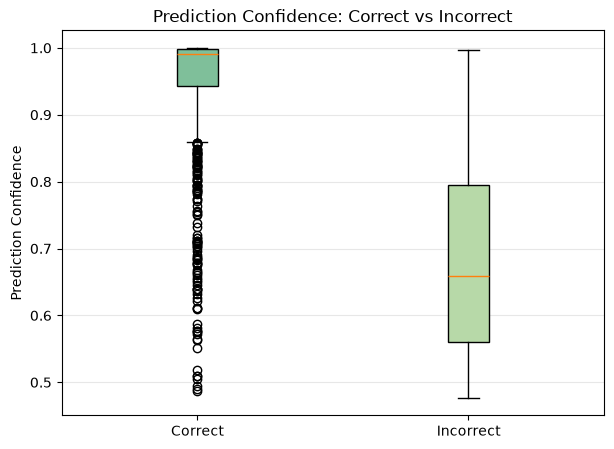

In [119]:
plt.figure(figsize=(7, 5))

box = plt.boxplot(
    [correct_confidence, incorrect_confidence],
    tick_labels=["Correct", "Incorrect"],
    patch_artist=True
)

colors = ["#7FBF9A", "#B7D9A8"]

for patch, color in zip(box["boxes"], colors):
    patch.set_facecolor(color)

plt.ylabel("Prediction Confidence")
plt.title("Prediction Confidence: Correct vs Incorrect")
plt.grid(axis="y", alpha=0.3)

plt.show()

### Prediction Confidence Analysis

The model shows a clear difference in confidence between correct and incorrect predictions.

- **Average confidence for correct predictions:** 94.2%
- **Average confidence for incorrect predictions:** 72.5%

Correct predictions are generally concentrated at very high confidence levels, while incorrect predictions show substantially lower and more varied confidence.

However, some incorrect predictions reach confidence levels close to 100%. This confirms what was observed in the misclassified examples: although lower confidence can indicate a difficult case, high confidence does not always guarantee a correct prediction.

This is particularly important in a real-world plant disease detection system, where confidence scores should not be interpreted as certainty.

---

### Precision, Recall & F1-score/ class - Bar chart
Collecting numbers from classification_report:

In [120]:
report_dict = classification_report(
    y_true,
    y_pred,
    target_names=display_labels,
    output_dict=True
)

In [121]:
metrics = ["precision", "recall", "f1-score"]

healthy_scores = [report_dict["Healthy"][metric] for metric in metrics]
early_scores = [report_dict["Early Blight"][metric] for metric in metrics]
late_scores = [report_dict["Late Blight"][metric] for metric in metrics]

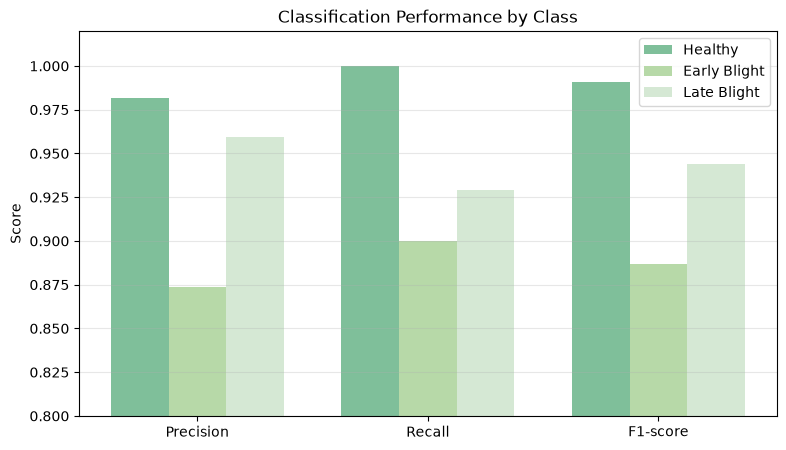

In [122]:
x = np.arange(len(metrics))
width = 0.25

plt.figure(figsize=(9, 5))

plt.bar(
    x - width,
    healthy_scores,
    width,
    label="Healthy",
    color="#7FBF9A"
)

plt.bar(
    x,
    early_scores,
    width,
    label="Early Blight",
    color="#B7D9A8"
)

plt.bar(
    x + width,
    late_scores,
    width,
    label="Late Blight",
    color="#D5E8D4"
)

plt.xticks(
    x,
    ["Precision", "Recall", "F1-score"]
)

plt.ylabel("Score")
plt.ylim(0.8, 1.02)
plt.title("Classification Performance by Class")
plt.legend()

plt.grid(axis="y", alpha=0.3)

plt.show()

### Classification Performance by Class

The class-level metrics show clear differences in model performance.

**Healthy** achieves almost perfect scores across precision, recall, and F1-score, confirming that the model can reliably distinguish healthy leaves from diseased leaves.

**Early Blight** has high recall (0.96) but lower precision (0.86). This means the model detects most actual Early Blight cases, but sometimes incorrectly predicts Early Blight for leaves belonging to another class.

**Late Blight** shows the opposite pattern, with very high precision (0.98) but lower recall (0.92). When the model predicts Late Blight it is usually correct, but some actual Late Blight cases are instead classified as Early Blight.

These results are consistent with the confusion matrix and confirm that the main classification challenge is distinguishing between Early Blight and Late Blight.

---

## Overall Model Evaluation

The different evaluation methods show a consistent pattern in the model's performance.

The training curves showed that the model learned quickly and reached high performance after only five epochs. Training accuracy reached **95.6%**, while validation accuracy reached **94.8%**, with no clear signs of significant overfitting.

The confusion matrix and classification metrics provide a more detailed picture. Healthy leaves were classified almost perfectly, while most errors occurred between **Early Blight and Late Blight**. Early Blight achieved high recall but lower precision, while Late Blight achieved high precision but slightly lower recall.

This pattern is also visible in the prediction examples. Healthy leaves were generally classified with very high confidence, while predictions for the disease classes showed greater variation. The misclassified examples further demonstrate the visual similarity between Early Blight and Late Blight.

The confidence analysis adds an important perspective. Correct predictions had an average confidence of **94.2%**, compared with **72.5%** for incorrect predictions. However, some incorrect predictions were made with confidence above 90%, showing that a high confidence score does not necessarily mean that a prediction is correct.

### Key Finding

Overall, the model is highly effective at distinguishing **healthy from diseased tomato leaves**. The main limitation is determining which of the two visually similar diseases is present.

This distinction is important from a practical perspective. A plant disease detection system could be useful as an early screening or decision-support tool, but the results suggest that predictions should not be treated as a definitive diagnosis, especially when distinguishing between similar diseases.

---

## Conclusion and Future Improvements

The transfer learning approach using MobileNetV2 successfully classified tomato leaves as **Healthy, Early Blight, or Late Blight**, achieving approximately **96% accuracy** on the validation dataset.

The strongest result was the model's ability to distinguish healthy leaves from diseased leaves. The main challenge was differentiating between Early Blight and Late Blight, which share similar visual characteristics.

From a practical perspective, these results demonstrate the potential of transfer learning for automated plant disease detection. A system based on this approach could help growers identify possible signs of disease quickly and support earlier intervention. However, the model should currently be considered a **decision-support tool rather than a definitive diagnostic system**, particularly because some incorrect predictions were made with high confidence.

### Future Improvements

Possible improvements include:

- Testing the model on a separate test dataset that was not used during development.
- Using data augmentation to increase variation in the training data.
- Fine-tuning selected layers of MobileNetV2 to better distinguish between visually similar diseases.
- Evaluating the model on real-world images taken under different lighting conditions, backgrounds, and camera angles.
- Expanding the model to recognize additional tomato diseases and plant species.
- Investigating confidence thresholds so uncertain predictions can be flagged for further review.

Overall, the project demonstrates how a pretrained image model can be adapted to a specialized agricultural problem with relatively little additional training.